# Introduction

This mini-project uses credit scoring to demonstrate a complete ML evaluation workflow, where prediction accuracy, interpretability, and fairness must be assessed together. Using a PyTorch neural network trained on structured financial data, we explore model evaluation, threshold analysis, explainability, and fairness auditing in a realistic risk prediction setting.

# Import packages

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Generate dataset

In [2]:
np.random.seed(42)

n = 5000

income = np.random.normal(60000, 18000, n)
debt_to_income = np.random.beta(2, 5, n)
credit_utilization = np.random.beta(2, 3, n)
late_payments = np.random.poisson(0.4, n)
employment_years = np.random.exponential(5, n)
loan_amount = np.random.normal(15000, 5000, n)
age = np.random.normal(40, 12, n)

risk_score = (
    2.5 * debt_to_income
    + 2.0 * credit_utilization
    + 0.7 * late_payments
    - 0.000015 * income
    - 0.05 * employment_years
    + 0.00003 * loan_amount
)

prob_default = 1 / (1 + np.exp(-risk_score))
default = (np.random.rand(n) < prob_default).astype(int)

df = pd.DataFrame({
    "income": income,
    "debt_to_income": debt_to_income,
    "credit_utilization": credit_utilization,
    "late_payments": late_payments,
    "employment_years": employment_years,
    "loan_amount": loan_amount,
    "age": age,
    "default": default
})

# Feature engineering

In [3]:
features = [
    "income",
    "debt_to_income",
    "credit_utilization",
    "late_payments",
    "employment_years",
    "loan_amount",
    "age"
]

X = df[features].values
y = df["default"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# Model

In [4]:
class CreditRiskModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Training

In [5]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64,
    shuffle=True
)

model = CreditRiskModel(input_dim=len(features))

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(30):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        probabilities = model(batch_X)
        loss = criterion(probabilities, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}, loss: {total_loss / len(train_loader):.4f}")

Epoch 5, loss: 0.5398
Epoch 10, loss: 0.5343
Epoch 15, loss: 0.5332
Epoch 20, loss: 0.5324
Epoch 25, loss: 0.5315
Epoch 30, loss: 0.5296


# Model evaluation

In [6]:
model.eval()

with torch.no_grad():
    y_prob = model(X_test_tensor).numpy().flatten()

threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Average precision:", average_precision_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

[[ 48 230]
 [ 28 694]]
              precision    recall  f1-score   support

           0       0.63      0.17      0.27       278
           1       0.75      0.96      0.84       722

    accuracy                           0.74      1000
   macro avg       0.69      0.57      0.56      1000
weighted avg       0.72      0.74      0.68      1000

ROC AUC: 0.6972089918093226
Average precision: 0.7499544075499756
Precision: 0.7510822510822511
Recall: 0.961218836565097
F1: 0.8432563791008505


## ROC Curve

The ROC curve shows ranking quality across thresholds.

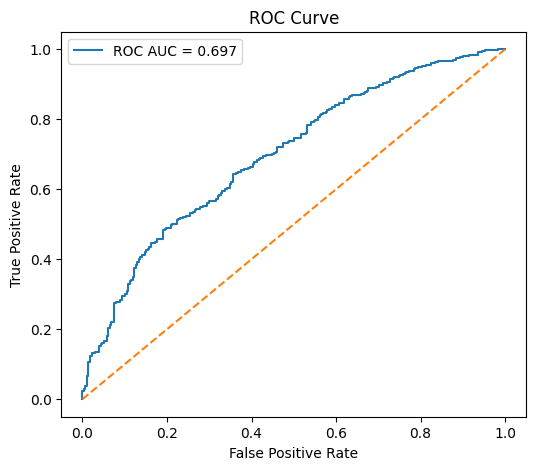

In [7]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve

The precision–recall curve is often more informative for credit risk, fraud, or default prediction because positive cases may be relatively rare.

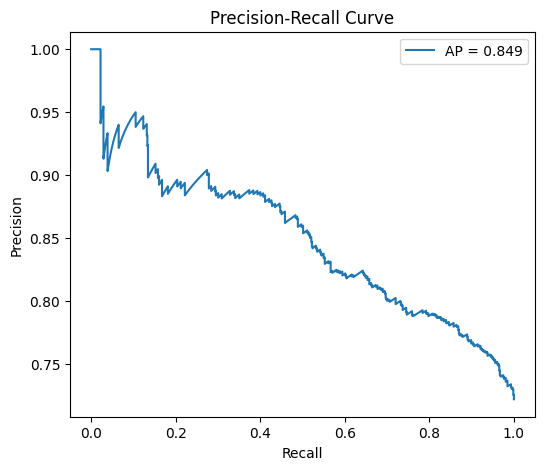

In [8]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_prob):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## Threshold analysis

Threshold analysis makes the operational tradeoff explicit.

In [9]:
threshold_rows = []

for threshold in np.arange(0.1, 0.9, 0.1):
    preds = (y_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "predicted_default_rate": preds.mean()
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df)

   threshold  precision    recall        f1  predicted_default_rate
0        0.1   0.722000  1.000000  0.838560                   1.000
1        0.2   0.723447  1.000000  0.839535                   0.998
2        0.3   0.726083  0.998615  0.840816                   0.993
3        0.4   0.733607  0.991690  0.843345                   0.976
4        0.5   0.751082  0.961219  0.843256                   0.924
5        0.6   0.772672  0.885042  0.825048                   0.827
6        0.7   0.809446  0.688366  0.744012                   0.614
7        0.8   0.885093  0.394737  0.545977                   0.322


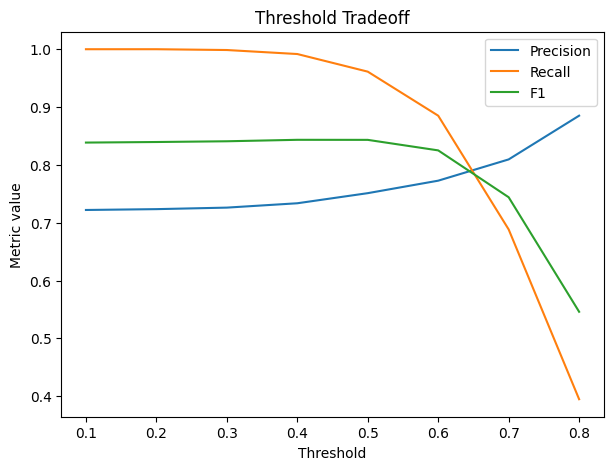

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold Tradeoff")
plt.legend()
plt.show()

In [11]:
results = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled),
    columns=features
)

results["actual"] = y_test
results["probability"] = y_prob
results["prediction"] = y_pred

results["error_type"] = "correct"
results.loc[(results["actual"] == 0) & (results["prediction"] == 1), "error_type"] = "false_positive"
results.loc[(results["actual"] == 1) & (results["prediction"] == 0), "error_type"] = "false_negative"

print(results["error_type"].value_counts())

error_type
correct           742
false_positive    230
false_negative     28
Name: count, dtype: int64


False positives are applicants predicted as likely to default who did not default. False negatives are applicants predicted as safe who did default. In credit scoring, both matter, but they represent different business risks.

In [12]:
error_summary = results.groupby("error_type")[features + ["probability"]].mean()
print(error_summary)

                      income  debt_to_income  credit_utilization  \
error_type                                                         
correct         60035.866476        0.293077            0.418559   
false_negative  71417.839474        0.203142            0.274613   
false_positive  59967.544019        0.249403            0.380320   

                late_payments  employment_years   loan_amount        age  \
error_type                                                                 
correct              0.452830          4.920808  15172.691284  40.649320   
false_negative       0.142857         11.012544  12451.681404  39.243072   
false_positive       0.243478          4.667096  14734.580091  39.967638   

                probability  
error_type                   
correct            0.743099  
false_negative     0.428880  
false_positive     0.701108  


A compact plot can reveal whether errors cluster in certain feature ranges.

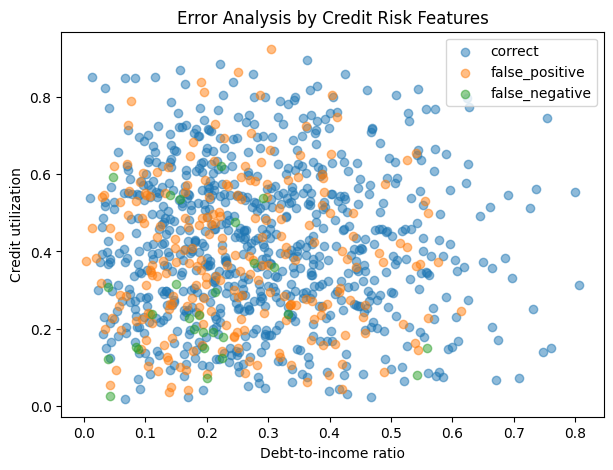

In [13]:
plt.figure(figsize=(7, 5))

for error_type in ["correct", "false_positive", "false_negative"]:
    subset = results[results["error_type"] == error_type]
    plt.scatter(
        subset["debt_to_income"],
        subset["credit_utilization"],
        label=error_type,
        alpha=0.5
    )

plt.xlabel("Debt-to-income ratio")
plt.ylabel("Credit utilization")
plt.title("Error Analysis by Credit Risk Features")
plt.legend()
plt.show()

# Explainability


## SHAP values

For a credit-scoring model, explanations matter because decisions affect real people. We can use SHAP to estimate how each feature contributes to individual predictions.

In [14]:
import shap

background = X_train_tensor[:200]
sample = X_test_tensor[:200]

explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(sample)

shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values

For a single applicant, SHAP values help identify which features pushed the prediction toward higher or lower risk. High credit utilization, high debt-to-income ratio, and repeated late payments may increase predicted risk. Higher income or longer employment history may reduce it.

/tmp/ipykernel_16/3653410377.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


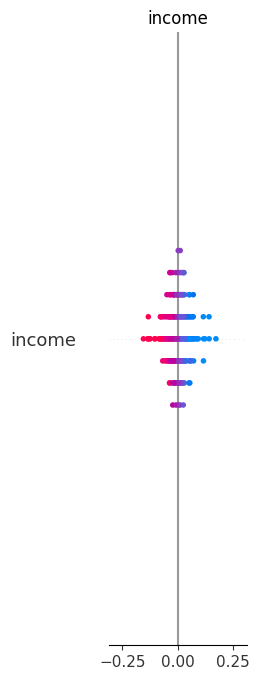

In [15]:
shap.summary_plot(
    shap_values_array,
    sample.numpy(),
    feature_names=features
)

/tmp/ipykernel_16/348133503.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


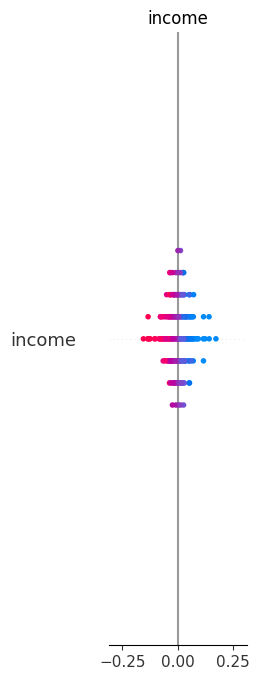

In [16]:
shap.summary_plot(
    shap_values_array,
    sample.numpy(),
    feature_names=features,
    plot_type="bar"
)

For an individual applicant, SHAP can show which features pushed the predicted default probability upward or downward.

## LIME

In [17]:
from lime.lime_tabular import LimeTabularExplainer

def predict_proba_for_lime(data):
    data_tensor = torch.FloatTensor(data)

    model.eval()
    with torch.no_grad():
        default_prob = model(data_tensor).numpy().flatten()

    non_default_prob = 1 - default_prob

    return np.column_stack([non_default_prob, default_prob])

In [18]:
applicant_index = 0

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=features,
    class_names=["non_default", "default"],
    mode="classification"
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_scaled[applicant_index],
    predict_fn=predict_proba_for_lime,
    num_features=6
)

lime_exp.show_in_notebook(show_table=True)

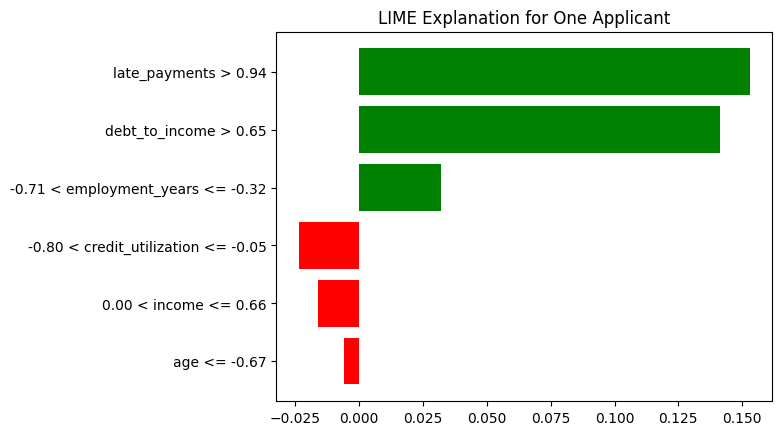

In [19]:
fig = lime_exp.as_pyplot_figure()
plt.title("LIME Explanation for One Applicant")
plt.show()

SHAP and LIME should not be interpreted as causal truth. They explain the model’s behavior, not the real world. If SHAP says high credit utilization increased predicted default risk, that means the model used that feature in that direction for this prediction. It does not prove that changing utilization alone would causally change the borrower’s true default risk.

## Combine explanation with error analysis

In [20]:
false_negatives = results[results["error_type"] == "false_negative"]
false_positives = results[results["error_type"] == "false_positive"]

print("False negatives with highest predicted safety:")
print(false_negatives.sort_values("probability").head())

print("False positives with highest predicted risk:")
print(false_positives.sort_values("probability", ascending=False).head())

False negatives with highest predicted safety:
           income  debt_to_income  credit_utilization  late_payments  \
662  56561.500273        0.194614            0.192275            0.0   
895  63944.705898        0.039912            0.307311            0.0   
774  70303.025601        0.308925            0.359455            0.0   
220  63427.630019        0.179885            0.200461            0.0   
803  59096.316893        0.200107            0.073282            0.0   

     employment_years   loan_amount        age  actual  probability  \
662         14.307220   6980.551148  49.608056       1     0.281112   
895         18.772426  14453.127632  18.914925       1     0.348545   
774         21.463467  13575.491391  38.462577       1     0.376810   
220          8.316729   7557.337384  44.016009       1     0.378041   
803          5.442848   8235.312905  41.610478       1     0.395087   

     prediction      error_type  
662           0  false_negative  
895           0  false_ne

In [21]:
applicant_index = 0

print("Predicted default probability:", y_prob[applicant_index])

applicant_original = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled[applicant_index].reshape(1, -1)),
    columns=features
)

print(applicant_original)

Predicted default probability: 0.95812416
         income  debt_to_income  credit_utilization  late_payments  \
0  67733.127944        0.486973            0.371891            2.0   

   employment_years   loan_amount       age  
0           2.53955  18274.438799  3.586515  


In [22]:
confident_errors = results[
    ((results["error_type"] == "false_positive") & (results["probability"] > 0.8)) |
    ((results["error_type"] == "false_negative") & (results["probability"] < 0.2))
]

print(confident_errors)

           income  debt_to_income  credit_utilization  late_payments  \
0    67733.127944        0.486973            0.371891            2.0   
6    43363.803403        0.256565            0.592482            0.0   
99   55777.431599        0.303936            0.661799            0.0   
105  38645.944312        0.136357            0.618964            1.0   
110  37239.028675        0.287193            0.803679            0.0   
150  40349.384229        0.305388            0.922743            0.0   
180  54980.098905        0.514448            0.420940            0.0   
186  29353.495124        0.212669            0.633954            0.0   
188  36951.799722        0.076712            0.789787            1.0   
208  62880.328065        0.425943            0.184534            1.0   
239  34407.407999        0.362412            0.725008            1.0   
245  61432.761523        0.278146            0.582162            0.0   
263  58384.757503        0.526087            0.635997           

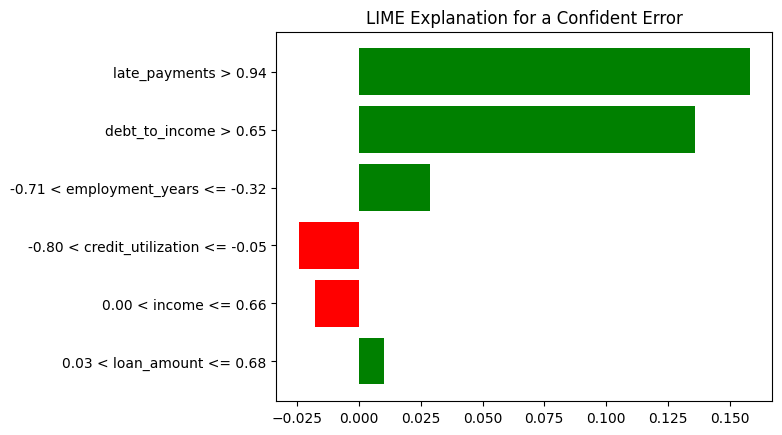

In [23]:
if len(confident_errors) > 0:
    idx = confident_errors.index[0]

    local_position = results.index.get_loc(idx)

    lime_exp = lime_explainer.explain_instance(
        data_row=X_test_scaled[local_position],
        predict_fn=predict_proba_for_lime,
        num_features=6
    )

    fig = lime_exp.as_pyplot_figure()
    plt.title("LIME Explanation for a Confident Error")
    plt.show()